In [1]:
!gdown 1yvVfxwNQ4H0ODgXw6d95qE0QfiCETvR7 # train.csv
!gdown 1bTuiLLYLPPwXJQJ0LrhOB0QuFG-Bh2HA # test.csv

Downloading...
From: https://drive.google.com/uc?id=1yvVfxwNQ4H0ODgXw6d95qE0QfiCETvR7
To: /content/train.csv
100% 17.2M/17.2M [00:00<00:00, 44.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1bTuiLLYLPPwXJQJ0LrhOB0QuFG-Bh2HA
To: /content/test.csv
100% 3.76M/3.76M [00:00<00:00, 24.6MB/s]


# 1.EDA и Preprocessing - Изучение структуры данных и обработка.


## **Общий обзор признаков**

In [2]:
import pandas as pd

train_df = pd.read_csv("/content/train.csv")
test_df = pd.read_csv("/content/test.csv")



print("Тренировочные данные")
print(train_df.head(5))
print()
print("Тестовые данные")
print(test_df.head(5))

Тренировочные данные
   Unnamed: 0  Sentence_id           Word  POS  Tag
0           0          1.0      Thousands  NNS    0
1           1          NaN             of   IN    0
2           2          NaN  demonstrators  NNS    0
3           3          NaN           have  VBP    0
4           4          NaN        marched  VBN    0

Тестовые данные
   Unnamed: 0  Sentence_id   Word POS
0           0         11.0    The  DT
1           1          NaN   step  NN
2           2          NaN   will  MD
3           3          NaN  allow  VB
4           4          NaN    the  DT


Проанализируем две выборки на пропущенные, уникальные значения. Узнаем тип данных каждого столбца.

Тренировочные данные:

In [3]:
eda_report = pd.DataFrame({
    "dtype": train_df.dtypes,
    "missing": train_df.isnull().sum(),
    "missing_%": (train_df.isnull().sum() / len(train_df)) * 100,
    "unique": train_df.nunique()
})

eda_report

,dtype,missing,missing_%,unique
Unnamed: 0,int64,0,0.000000,839364
Sentence_id,float64,800997,95.429039,38367
Word,object,9,0.001072,32056
POS,object,0,0.000000,42
Tag,int64,0,0.000000,17


Тестовые данные:

In [4]:
eda_report_test = pd.DataFrame({
    "dtype": test_df.dtypes,
    "missing": test_df.isnull().sum(),
    "missing_%": (test_df.isnull().sum() / len(test_df)) * 100,
    "unique": test_df.nunique()
})

eda_report_test

,dtype,missing,missing_%,unique
Unnamed: 0,int64,0,0.000000,209211
Sentence_id,float64,199619,95.415155,9592
Word,object,1,0.000478,16877
POS,object,0,0.000000,41


In [5]:
print(f"Размер train: {train_df.shape}")
print(f"Размер test: {test_df.shape}")

Размер train: (839364, 5)
Размер test: (209211, 4)


## **Столбец "Unnamed: 0"**

Дублирует индексы строк => не несет полезной информ. => подлежит удалению

In [6]:
train_df = train_df.drop(columns=["Unnamed: 0"])
test_df = test_df.drop(columns=["Unnamed: 0"])
print("Тренировочные данные")
print(train_df.head(5))
print()
print("Тестовые данные")
print(test_df.head(5))

Тренировочные данные
   Sentence_id           Word  POS  Tag
0          1.0      Thousands  NNS    0
1          NaN             of   IN    0
2          NaN  demonstrators  NNS    0
3          NaN           have  VBP    0
4          NaN        marched  VBN    0

Тестовые данные
   Sentence_id   Word POS
0         11.0    The  DT
1          NaN   step  NN
2          NaN   will  MD
3          NaN  allow  VB
4          NaN    the  DT


## **Столбец "Sentence_id"**

У данного столбца 95% пропущенных значений.
В описании : Dataset contains English sentenses with labeled part of speach (POS) for each word and Tag for named entity type. Sentences was gathered from news.". Это значит, что Sentence_id нужен и вероятно указывает на предложение.
Нецелесообразно удалять этот столбец...


In [7]:
train_df[train_df["Sentence_id"].notna()].head(20) # Посмотрим на не Nan значения Sentence_id

,Sentence_id,Word,POS,Tag
0,1.0,Thousands,NNS,0
24,2.0,Families,NNS,0
54,3.0,They,PRP,0
68,4.0,Police,NNS,0
83,5.0,The,DT,0
108,6.0,The,DT,0
132,7.0,The,DT,0
153,8.0,The,DT,0
181,9.0,Iran,NNP,3
196,10.0,Iranian,JJ,3


Видно, что присутствует некая периодичность в данных. Проанализируем...

In [8]:
sentence_positions = train_df[train_df["Sentence_id"].notna()].index #Отбираем существующие знач-я
(sentence_positions.to_series().diff()).describe() # вычисляем разницу между соседними

,0
count,38366.000000
mean,21.877600
std,7.971753
min,1.000000
25%,16.000000
50%,21.000000
75%,27.000000
max,104.000000


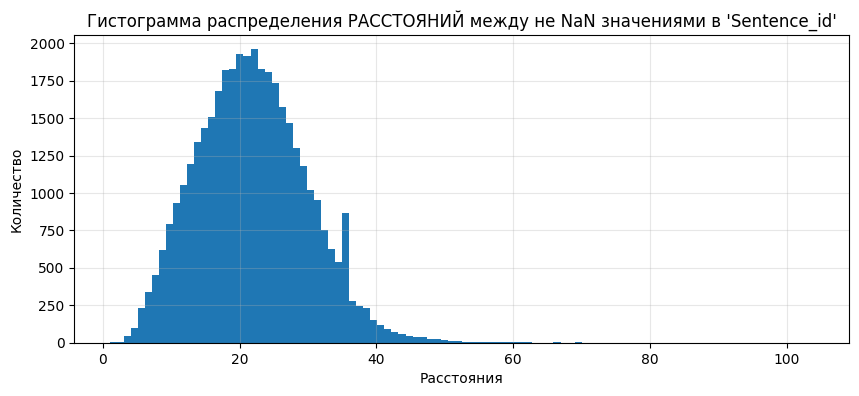

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
gap_lengths = sentence_positions.to_series().diff().iloc[1:] # Не учитываем первое значение, там diff == Nan
plt.hist(gap_lengths, bins=100)
plt.title("Гистограмма распределения РАССТОЯНИЙ между не NaN значениями в 'Sentence_id'")
plt.xlabel("Расстояния")
plt.ylabel("Количество")
plt.grid(True, alpha=0.3)
plt.show()

В среднем расстояние между не NaN значениями в датасете ~~ 20-21 объекта-слова. Учитывая, что датасет хранит предложения, делаем вывод, что существующ.значения `Sentence_id ` указывают на начало предложений.

В таком случае,
1. В среднем длина предложения 21-22 слова.
2. Максимальная длина предложения в датасета 104 слова.
3. Минимальная длина - 1 слово.

Столбец `Sentence_id`  **НУЖЕН** для дальнейшей работы.



Понятно, что обработать значения NaN нельзя, поэтому заменим эти значения на id предложения, к которому принадлежат слова.

Более технически: заменим значения NaN на ближайшее сверху значение `Sentence_id`.

In [10]:
train_df["Sentence_id"] = train_df["Sentence_id"].ffill()
test_df["Sentence_id"] = test_df["Sentence_id"].ffill()

In [11]:
print(f" Train: {train_df['Sentence_id'].isna().sum()}\n Test: { test_df['Sentence_id'].isna().sum()}") # Проверяем пропуски

 Train: 0
 Test: 0


Проверяем...

In [12]:
train_df[["Sentence_id", "Word","POS"]].head(30)

,Sentence_id,Word,POS
0,1.0,Thousands,NNS
1,1.0,of,IN
2,1.0,demonstrators,NNS
3,1.0,have,VBP
4,1.0,marched,VBN
5,1.0,through,IN
6,1.0,London,NNP
7,1.0,to,TO
8,1.0,protest,VB
9,1.0,the,DT


Проверка успешна. Мы соотнесли каждое слово своему предложению.

## **Столбец "Word"**

Пропущенные значения составляют очень низкий процент (0,001%) от всех данных. Посмотрим на эти строки.

In [13]:
train_df[train_df["Word"].isnull()]


,Sentence_id,Word,POS,Tag
158090,9047.0,NaN,NN,0
204641,11709.0,NaN,NN,0
205425,11759.0,NaN,NN,0
491543,28049.0,NaN,NN,0
598127,34152.0,NaN,NN,0
722730,41181.0,NaN,NN,0
723818,41244.0,NaN,NN,0
757007,43177.0,NaN,NN,0
803375,45887.0,NaN,NN,0


In [14]:
test_df[test_df["Word"].isnull()]

,Sentence_id,Word,POS
113386,26129.0,NaN,NN


Эти строки можно удалить. Они не несут никакой информации.

In [15]:
train_df = train_df.dropna(subset=["Word"])

test_df = test_df.dropna(subset=["Word"])

print(test_df.loc[113380:113392, ["Sentence_id", "Word"]])

        Sentence_id       Word
113380      26104.0      rates
113381      26104.0         to
113382      26104.0       fend
113383      26104.0        off
113384      26104.0  inflation
113385      26104.0          .
113387      26129.0         of
113388      26129.0        the
113389      26129.0   injuries
113390      26129.0        are
113391      26129.0       said
113392      26129.0         to


## **Столбец "Pos"**

POS (Part-of-Speech) — это часть речи для каждого токена (слова/знака пунктуации).


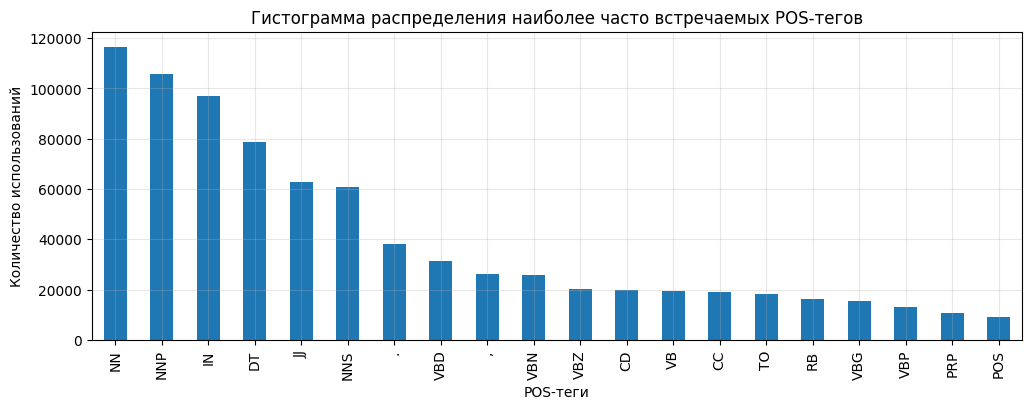

In [16]:
pos_counts = train_df["POS"].value_counts()
plt.figure(figsize=(12,4))
pos_counts.head(20).plot(kind="bar") # берём первые 20 элементов из pos_counts
plt.title("Гистограмма распределения наиболее часто встречаемых POS-тегов")
plt.xlabel("POS-теги")
plt.ylabel("Количество использований")
plt.grid(True, alpha=0.3)
plt.show()

Выше мы построили график распределения частей речи, выделив 20 наиболее часто встречаемых частей речи.

Наиболее часто встречающиеся части - имена существительные(NN, NNP, NNS), служебные части речи (IN, DT), имена прилагательные (JJ), глаголы (VB..) и знаки пунктуации.

Учитывая, что предложения были собраны из новостных источников, такое распределение выглядит естественным.

Оценим какие части речи чаще всего являются именованными сущностями (Tag ≠ 0), а какие — обычными словами (Tag = 0, то есть "O").

In [17]:
pos_ent = train_df.loc[train_df["Tag"] != 0, "POS"].value_counts(normalize=True) * 100
pos_o = train_df.loc[train_df["Tag"] == 0, "POS"].value_counts(normalize=True) * 100

compare = pd.DataFrame({"entities_%": pos_ent, "O_%": pos_o}).fillna(0)
compare.sort_values("entities_%", ascending=False).head(15)

,entities_%,O_%
POS,,
NNP,77.757684,0.748330
JJ,9.978268,7.029408
CD,4.500155,1.963083
NN,1.737038,16.098886
IN,1.555418,13.368613
NNPS,1.393201,0.031386
NNS,1.253493,8.335222
CC,0.494412,2.589671
DT,0.374884,11.018627


По итогу почти 78% всех слов, которые размечены как сущности, имеют POS == NNP (имя собственное). Это такие сущности как PERSON/ORG/LOC в новостных текстах.Далее по частоте идут прилагательные (9%) и числительные (4,5%). Числительные наиболее вероятно связаны с сущностями типа DATE/MONEY/PERCENT. Менее всего сущностями преставлены различные существительные (NN, NNPS, NNS), служебные части речи, числительные (CD).

В то же время среди не-сущностей (O) преобладают служебные части речи (DT, IN) и общие существительные (NN, NNS).

## **Столбец "Tag"**

Датасет размечен согласно формату IOB2. Формат данных IOB2 для задачи NER — способ разметки текста, при котором каждому токену (словоформе) присваивается `метка`, указывающая, является ли он частью именованной сущности и если да, то какой именно. Расшифровка аббревиатуры IOB2:

B- (Beginning) — начало именованной сущности,
I- (Inside) — продолжение именованной сущности,
O (Outside) — токен не относится к именованной сущности.

Столбец `Tag` как раз содержит эти `метки`.

In [18]:
train_df["Tag"].value_counts()

,count
Tag,
0,710515
7,30338
13,16239
15,16140
2,13903
1,13573
16,13462
3,12662
8,5987


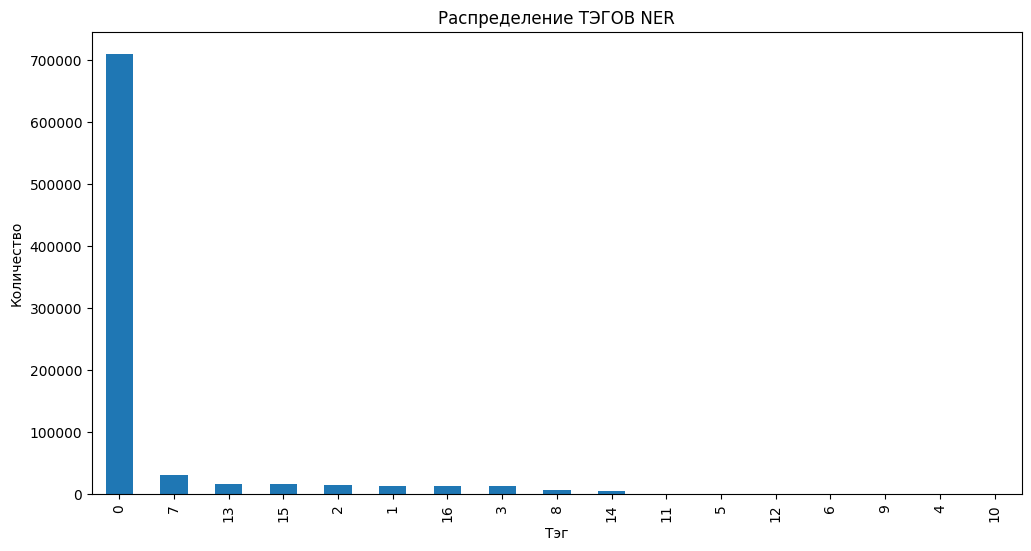

In [19]:
train_df["Tag"].value_counts().plot(kind="bar", figsize=(12,6))
plt.title("Распределение ТЭГОВ NER")
plt.xlabel("Тэг")
plt.ylabel("Количество")
plt.show()

Из описания датасета, как впрочем и из графика выше, видим, что `Tag` - признак, содержащий числа int. Каждое число представляет собой TAG (например, B-per или I-org).

In [20]:
tag_counts = train_df["Tag"].value_counts()
tag_share = (tag_counts / len(train_df) * 100).round(3)

print("Наиболее встречаемые теги:\n", tag_share.head(10))
print("\nРедкие теги (<0.05%):\n", tag_share[tag_share < 0.05])

Наиболее встречаемые теги:
 Tag
0     84.650
7      3.614
13     1.935
15     1.923
2      1.656
1      1.617
16     1.604
3      1.509
8      0.713
14     0.614
Name: count, dtype: float64

Редкие теги (<0.05%):
 Tag
11    0.038
5     0.030
12    0.029
6     0.025
9     0.020
4     0.018
10    0.005
Name: count, dtype: float64


Отметим факт наличия дисбаланса в целевом признаке `Tag` . На гистограмме и далее численно продемонстрировано , что метка "0" составляет ~85% значений в этом признаке.

## **Группировка данных по предложениям**

После восстановления пропущенных значений в Sentence_id данные всё ещё остаются "раздробленными". Они представлены в построчном формате, где каждая строка соответствует одному токену.

Для подачи в модель сгруппируем слова в один объект. В таком случае в качестве объектов сможем рассматривать предложения.

In [21]:
train_sentences = [] # список  предложений как списков слов
train_labels = [] #  теги для этих предложений

train_sentence_ids = [] # ID предложений

for sid, grp in train_df.groupby("Sentence_id", sort=False): # Группируем train_df по Sentence_id.
    train_sentence_ids.append(sid) # Сохраняем id-шник
    train_sentences.append(grp["Word"].tolist())  # Собираем слова предложения
    train_labels.append(grp["Tag"].tolist())  # и теги


Аналогично для TEST

In [22]:
test_sentences = []

test_sentence_ids = []

for sid, grp in test_df.groupby("Sentence_id", sort=False):
    test_sentence_ids.append(sid)
    test_sentences.append(grp["Word"].tolist())


In [23]:
print("Кол-во train предложения:", len(train_sentences))
print("Кол-во списков с тегами для train:", len(train_labels))
print("Одинаковые ли длины:", all(len(s) == len(l) for s, l in zip(train_sentences, train_labels)))

Кол-во train предложения: 38367
Кол-во списков с тегами для train: 38367
Одинаковые ли длины: True


Пример

In [24]:
i = 1
print("Sentence_id:", train_sentence_ids[i])
print("Words:", train_sentences[i][:45])
print("Tags:", train_labels[i][:45])


Sentence_id: 2.0
Words: ['Families', 'of', 'soldiers', 'killed', 'in', 'the', 'conflict', 'joined', 'the', 'protesters', 'who', 'carried', 'banners', 'with', 'such', 'slogans', 'as', '"', 'Bush', 'Number', 'One', 'Terrorist', '"', 'and', '"', 'Stop', 'the', 'Bombings', '.', '"']
Tags: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


# 2. Выбор модели. Токенизация данных.

На основе полученной информации о данных готовим данные для модели.

В современном NLP для задачи NER традиционно подходят модели, основанные на архитектуре BERT (Bidirectional Encoder Representations from Transformers). На это есть несколько причин.

1. Двунаправленный контекст

BERT анализирует текст сразу в двух направлениях — слева направо и справа налево, что позволяет учитывать контекст до и после каждого слова.  Например, слово «Apple» может быть как фруктом, так и компанией, и только контекст позволяет правильно его классифицировать.

2. Механизм внимания (attention)

BERT основан на архитектуре трансформера, использующей механизм внимания, который позволяет модели фокусироваться на наиболее значимых частях текста при анализе каждого токена. Это помогает точнее определять границы и типы сущностей, даже если они встречаются в сложных или длинных предложениях.

3. Контекстно-зависимые эмбеддинги

В отличие от классических моделей (например, word2vec), которые создают одно представление для слова вне зависимости от контекста, BERT формирует уникальное векторное представление каждого слова с учётом его окружения. Это позволяет различать омонимы (например, смартфон «Apple» и фрукт) и правильно определять сущности в разных ситуациях.

В этой работе мы будем использовать BERT.

## Токенизация

Берем тренировочные данные train.csv и выполняем их токенизацию для подачи в модель.

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    train_sentences, train_labels,
    test_size=0.1, # 10% на валидац. часть
    random_state=42
)

print(len(X_train), len(X_val))
print("Длины равны:", all(len(s)==len(l) for s,l in zip(X_train, y_train))) # Доп. проверка. Если длины равны, то данные поделились без нарушений соответствия меток-тегов и слов

34530 3837
Длины равны: True


Для корректного соответствия токенов с разметкой слов при использовании таких моделей, как BERT, **текст разбивается на токены**, а не на слова целиком. То есть сейчас мы готовим всё, чтобы на следующем шаге можно было корректно обучить BERT.

In [26]:
from transformers import AutoTokenizer

model_ckpt = "bert-base-cased" # bert-base — модель среднего размера.
# Для cased версии токенизатор не приводит текст к нижнему регистру.
# Как итог мы получаем еще один источник информации.
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
# Мы выбрали версию BERT и создаём токенизатор для неё


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]






Чтобы **правильно сопоставить метки сущностей с токенами**, требуется дополнительная обработка, например, распространение метки первого подслова на все подслова или игнорирование меток для вспомогательных токенов.




In [27]:
from datasets import Dataset
# До текущего момента соответствие X и Y регулировалось вручную.
# Создаем таблицу с помощью Dataset для хранения наших данных
# Dataset автоматизирует большинство работы
train_ds = Dataset.from_dict({"tokens": X_train, "ner_tags": y_train})
val_ds = Dataset.from_dict({"tokens": X_val,"ner_tags": y_val})


# Метки сущностей (ner_tags) в датасете заданы для слов,
# а BERT работает с токенами, которые могут быть частями слова - субсловами (subwords).
# Функция далее выполняют токенизацию, специфичную для конкретных (наших) данных.
# Теперт мы создаем соответствие токенов для BERT и  метки по токенам
def tokenize_and_align_labels(examples):
    tokenized = tokenizer( # Для каждого предложения создаем токенизатор
        examples["tokens"], # Передаем предложения (списки слов) батчами.
        is_split_into_words=True, # Предохранитель от склеивания слов в цельную строку. У нас так уже есть соответствие "слово -> тег"
        truncation=True # Во избежание ошибки на входе модели длинные строки обрезаются
    ) # Здесь мы токенизируем
    # Список для итоговых меток по батчу
    aligned_labels = [] # Будет хранить результат для каждого предложения по батчу


    # Восстанавливаем соответствие меток-тегов и токенизир. слов
    for i, word_labels in enumerate(examples["ner_tags"]): # Идем по каждому предложению батча. word_labels — список тегов слов одного предложения
        word_ids = tokenized.word_ids(batch_index=i) # Получаем список, где каждому токену соответствует исходное слово. Определяет какие subwords какому слову принадлежат

        prev_word_id = None
        label_ids = [] # Хранение тегов каждого ТОКЕНА предложения
        for word_id in word_ids: #  Проход по токенам ОДНОГО предложения
            if word_id is None:
                label_ids.append(-100) # спец-токены для субслов / padding. HuggingFace Trainer и модели для токен-классификации ожидают именно это значение.
            elif word_id != prev_word_id: # Если текущ. токен отличается от предыдущего ==> началось новое слово
                label_ids.append(word_labels[word_id])  # Соотносим тег к этому слову ЛИБО к первому подслову этого слова
            else:
                label_ids.append(-100) # Помечаем служебным токеном последующие подслова(если встречаются)
            prev_word_id = word_id

        aligned_labels.append(label_ids) # В конце хранит теги для всех предложений в батче

    tokenized["labels"] = aligned_labels # Готовые данные одного батча
    return tokenized

train_tok = train_ds.map(tokenize_and_align_labels, batched=True) # Делим на батчи и применяем функцию выше к каждому
val_tok = val_ds.map(tokenize_and_align_labels, batched=True)

Map:   0%|          | 0/34530 [00:00<?, ? examples/s]

Map:   0%|          | 0/3837 [00:00<?, ? examples/s]

Создадим  два словаря соответствия: id2tag и tag2id. Словарь id2tag переводит числовой код класса в текстовый BIO-тег, а tag2id выполняет обратное преобразование.

In [28]:
id2tag = {
  0: "O",
  1: "B-per", 2: "I-per",
  3: "B-gpe", 4: "I-gpe",
  5: "B-eve", 6: "I-eve",
  7: "B-geo", 8: "I-geo",
  9: "B-nat", 10:"I-nat",
  11:"B-art", 12:"I-art",
  13:"B-tim", 14:"I-tim",
  15:"B-org", 16:"I-org"
}
tag2id = {v:k for k,v in id2tag.items()}
tag2id

{'O': 0,
 'B-per': 1,
 'I-per': 2,
 'B-gpe': 3,
 'I-gpe': 4,
 'B-eve': 5,
 'I-eve': 6,
 'B-geo': 7,
 'I-geo': 8,
 'B-nat': 9,
 'I-nat': 10,
 'B-art': 11,
 'I-art': 12,
 'B-tim': 13,
 'I-tim': 14,
 'B-org': 15,
 'I-org': 16}

In [29]:
# Возьмем одно предложение из датасета (конкретный пример с токенами и метками-тегами)
i = 0
tokens = train_ds[i]["tokens"]
tags = train_ds[i]["ner_tags"]

tok = tokenizer(tokens, is_split_into_words=True, truncation=True)
word_ids = tok.word_ids()

subwords = tok.tokens()
print("Предложение:", tokens[:20])
print("Теги слов: ", tags[:20])
print("\nРазбивка на подслова:", subwords[:30])
print("Карта соответствия токенов и слов:", word_ids[:30])

# покажем пары subword -> label (если не -100)
aligned = tokenize_and_align_labels({"tokens":[tokens], "ner_tags":[tags]})["labels"][0] # Создаем батч из одного предложения
pairs = []
for sw, wid, lab in zip(subwords, word_ids, aligned): # Разбивка; принадлежность к слову; тег
    if lab == -100:
        pairs.append((sw, wid, "-100"))
    else:
        pairs.append((sw, wid, id2tag[int(lab)]))
pairs[:30]

Предложение: ['A', 'Vatican', 'spokesman', 'says', 'Pope', 'Benedict', 'is', 'willing', 'to', 'meet', 'with', 'victims', 'of', 'pedophile', 'priests', '.']
Теги слов:  [0, 15, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Разбивка на подслова: ['[CLS]', 'A', 'Vatican', 'spokesman', 'says', 'Pope', 'Benedict', 'is', 'willing', 'to', 'meet', 'with', 'victims', 'of', 'p', '##ed', '##op', '##hil', '##e', 'priests', '.', '[SEP]']
Карта соответствия токенов и слов: [None, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 13, 13, 13, 13, 14, 15, None]


[('[CLS]', None, '-100'),
 ('A', 0, 'O'),
 ('Vatican', 1, 'B-org'),
 ('spokesman', 2, 'O'),
 ('says', 3, 'O'),
 ('Pope', 4, 'B-per'),
 ('Benedict', 5, 'I-per'),
 ('is', 6, 'O'),
 ('willing', 7, 'O'),
 ('to', 8, 'O'),
 ('meet', 9, 'O'),
 ('with', 10, 'O'),
 ('victims', 11, 'O'),
 ('of', 12, 'O'),
 ('p', 13, 'O'),
 ('##ed', 13, '-100'),
 ('##op', 13, '-100'),
 ('##hil', 13, '-100'),
 ('##e', 13, '-100'),
 ('priests', 14, 'O'),
 ('.', 15, 'O'),
 ('[SEP]', None, '-100')]

## Реализация модели

Берём готовую архитектуру BERT для классификации токенов и обучаем её на твоих данных

In [30]:
print(train_tok.column_names)
print(train_tok[7].keys())

print("input_ids length:", len(train_tok[7]["input_ids"]))
print("attention_mask length:", len(train_tok[7]["attention_mask"]))
print("labels length:", len(train_tok[7]["labels"]))

['tokens', 'ner_tags', 'input_ids', 'token_type_ids', 'attention_mask', 'labels']
dict_keys(['tokens', 'ner_tags', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'])
input_ids length: 28
attention_mask length: 28
labels length: 28


In [31]:
from transformers import AutoModelForTokenClassification


model = AutoModelForTokenClassification.from_pretrained( # берём уже предобученную языковую модель
    model_ckpt, # Выбранная ранее модель
    num_labels=len(id2tag), # Кол-во предсказываемых тегов
    id2label=id2tag, # словарь: номер класса -> имя тега
    label2id={v: k for k, v in id2tag.items()} #  словарь: имя тега -> номер класса
)



model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [32]:
from transformers import DataCollatorForTokenClassification
from transformers import TrainingArguments

# Создаем сборщик батчей
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer) # Выравнивает входные данные каждого батча по длине, применяя паддинг

training_args = TrainingArguments( # Объявление гиперпараметров
    output_dir="./ner_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16, # Размер батча на train
    per_device_eval_batch_size=16, # Размер батча на val
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    load_best_model_at_end=True, # После обучения загружаем лучшую модель, а не последнюю
    metric_for_best_model="f1_macro", # Критерий выбора этой лучшей модели
    greater_is_better=True, # Для нашей метрики чем выше, тем лучше
    report_to="none"
)


Для корректной оценки работы недостаточно использовать готовые функции F1. На последних слоях BERT (FFNN + Softmax) мы получаем 17 логитов (в соответствии с числом тегов), которые объясняют насколько модель склоняется к каждому классу-тегу.

Мы должны также учесть специальные токены, которые не должны участвовать в оценке: служебные токены, padding и внутренние подслова, помеченные значением `-100`.

In [33]:
from sklearn.metrics import precision_recall_fscore_support
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    # Для каждого токена выбираем класс с максимальной оценкой
    predictions = np.argmax(logits, axis=-1)

    # Плоские списки всех истинных и предсказанных классов
    y_true = []
    y_pred = []

    # Идём по каждому предложению
    for pred_seq, label_seq in zip(predictions, labels):
        # Идём по токенам внутри предложения
        for pred_id, label_id in zip(pred_seq, label_seq):
            # Игнорируем спец-токены, padding и внутренние subword
            if label_id == -100:
                continue

            y_true.append(int(label_id))
            y_pred.append(int(pred_id))

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=sorted(id2tag.keys()),   # учитываем все классы задачи
        average="macro",
        zero_division=0
    )

    return {
        "precision": precision_macro,
        "recall": recall_macro,
        "f1_macro": f1_macro,
    }

## Обучение

Мы подготовили данные. Теперь переходим к обучению модели.

In [34]:
from transformers import Trainer

# Передаем в один объект всё, что нужно для обучения
trainer = Trainer(
    model=model, # загруженную модель
    args=training_args, # правила обучения, наши гиперпараметры
    train_dataset=train_tok, # две выборки: тренировоч. и валид.
    eval_dataset=val_tok,
    processing_class=tokenizer, # токенизатор
    data_collator=data_collator, # сборщик батчей
    compute_metrics=compute_metrics # функцию вычисления метрики
)

trainer.train()
metrics = trainer.evaluate()
print(metrics)

Epoch,Training Loss,Validation Loss,Precision,Recall,F1 Macro
1,0.094400,0.096635,0.659407,0.592875,0.609142
2,0.071500,0.092613,0.747872,0.631987,0.668832
3,0.055000,0.093072,0.737124,0.646477,0.676038


{'eval_loss': 0.09307152032852173, 'eval_precision': 0.7371237455138656, 'eval_recall': 0.6464765336097908, 'eval_f1_macro': 0.6760379304984742, 'eval_runtime': 12.6326, 'eval_samples_per_second': 303.739, 'eval_steps_per_second': 18.999, 'epoch': 3.0}


Сохраняем модель

In [35]:
save_dir = "/content/my_ner_model"

trainer.save_model(save_dir)
trainer.save_state()

In [36]:
import shutil
archive_path = "/content/my_ner_model"

shutil.make_archive(archive_path, "zip", save_dir)
print("Архив создан:", archive_path + ".zip")

Архив создан: /content/my_ner_model.zip


# Предсказание на тестовой выборке.

In [37]:
from datasets import Dataset
import numpy as np


test_ds = Dataset.from_dict({"tokens": test_sentences}) # Упаковываем тестовые данные в Dataset как и train/val

# Объявляем токенизатор
def tokenize_test(examples):
    encodings = tokenizer(
        examples["tokens"],
        is_split_into_words=True,
        truncation=True
    )

    all_word_ids = []
    for i in range(len(examples["tokens"])):
        word_ids = encodings.word_ids(batch_index=i)
        word_ids = [-1 if w is None else int(w) for w in word_ids]
        all_word_ids.append(word_ids)

    result = {
        "input_ids": encodings["input_ids"],
        "attention_mask": encodings["attention_mask"],
        "word_ids": all_word_ids,
    }

    # У BERT обычно есть token_type_ids, но у некоторых моделей их нет
    if "token_type_ids" in encodings:
        result["token_type_ids"] = encodings["token_type_ids"]

    return result

# Применяем токенизацию ко всей тестовой выборке по батчам.
test_tok = test_ds.map(tokenize_test,batched=True,remove_columns=test_ds.column_names )

print(test_tok)
print(test_tok[0].keys())


test_output = trainer.predict(test_tok)
test_logits = test_output.predictions # Получаем логиты по каждому тегу
test_preds = np.argmax(test_logits, axis=-1) # Макс. знач. логита показывает наиболее вероятный тег. Получаем в итоге предсказанные теги по токенам


# Далее преобразовываем предсказания модели с уровня токенов  на уровень исходных слов предложения

# Находим id тега "O"
o_tag_id = [k for k, v in id2tag.items() if v == "O"][0]

predicted_tags_per_sentence = [] #Итоговый результат по тесту. Для каждого предложения храним список предсказанных меток по словам

for i, pred_seq in enumerate(test_preds): # Идем по каждому предложению. К слову test_preds
    word_ids = test_tok[i]["word_ids"] # Карта - список, где каждому токену  сопоставлен индекс исходного слова.

    # Сразу создаём список тегов длины, равной числу слов в предложении
    # По умолчанию все слова считаем не-сущностями (тег O)
    sentence_tags = [o_tag_id] * len(test_sentences[i])

    used_word_ids = set() # Множество, для каких слов уже поставили теги
                          #

    for pred_id, word_id in zip(pred_seq, word_ids): # Проход по токенам и карте соответствия
        # Пропускаем спец-токены и padding
        if word_id == -1:
            continue

        # Берём только первый subword каждого слова
        if word_id not in used_word_ids: # если для слова с таким word_id тег не поставлен,
            sentence_tags[word_id] = int(pred_id) # записываем предсказанный класс в позицию этого слова
            used_word_ids.add(word_id)  # отмечаем, что это слово уже обработано

    predicted_tags_per_sentence.append(sentence_tags) # Для каждого предложения формируется список тегов по словам.




Map:   0%|          | 0/9592 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'word_ids', 'token_type_ids'],
    num_rows: 9592
})
dict_keys(['input_ids', 'attention_mask', 'word_ids', 'token_type_ids'])


In [38]:

# Проверяем, что для каждого предложения:
# число предсказанных тегов == числу слов
lengths_match = all(
    len(words) == len(tags)
    for words, tags in zip(test_sentences, predicted_tags_per_sentence))

print("Длины сходятся:", lengths_match)




Длины сходятся: True


Разворачивание предсказаний в построчный формат.
До этого мы сделали предсказание и получили метки/теги для каждого слова каждого предложения.

Однако на данный момент нам нужно выполнить преобразование списка предложений в тот формат, который был изначально дан в test.csv.

Иными словами, переводим предсказания из формата “по предложениям” в формат “по строкам таблицы test_df.

In [39]:
predicted_tags_flat = []

sent_idx = 0   # индекс текущего предложения
word_idx = 0   # индекс текущего слова внутри предложения

for _, row in test_df.iterrows():
    # Если в строке нет слова, оставляем пустое значение
    # (на случай, если такие строки в test_df всё ещё есть)
    if pd.isna(row["Word"]):
        predicted_tags_flat.append(None)
        continue

    # Берём предсказанный тег для текущего слова
    predicted_tags_flat.append(predicted_tags_per_sentence[sent_idx][word_idx])
    word_idx += 1

    # Если дошли до конца текущего предложения,
    # переходим к следующему предложению
    if word_idx == len(predicted_tags_per_sentence[sent_idx]):
        sent_idx += 1
        word_idx = 0

print("Длина predicted_tags_flat:", len(predicted_tags_flat))
print("Число строк в test_df:", len(test_df))

Длина predicted_tags_flat: 209210
Число строк в test_df: 209210


# Создание Submission.csv

In [40]:
# Загружаем шаблон submission
!gdown 19IY3Y2-5exWaOalW4swWONuo5TMhAYoB

Downloading...
From: https://drive.google.com/uc?id=19IY3Y2-5exWaOalW4swWONuo5TMhAYoB
To: /content/submission.csv
100% 1.98M/1.98M [00:00<00:00, 16.8MB/s]


In [41]:
submission_df = pd.read_csv("/content/submission.csv")

pred_df = test_df.copy()
pred_df["TARGET"] = predicted_tags_flat

# Переносим текущий индекс в колонку ID
pred_df = pred_df.reset_index().rename(columns={"index": "ID"})

submission_final = submission_df[["ID"]].merge(
    pred_df[["ID", "TARGET"]],
    on="ID",
    how="left"
)

submission_final["TARGET"] = submission_final["TARGET"].fillna(0).astype(int)

submission_final.to_csv("submission_final.csv", index=False)
print(submission_final.head())

   ID  TARGET
0   0       0
1   1       0
2   2       0
3   3       0
4   4       0
